# **Multiple Instance Deep AUC Maximization with attention pooling (MIDAM-att) on Histopathology (Image) Dataset**

**Author**: Dixian Zhu \
**Edited by**: Zhuoning Yuan 

**Introduction**

In this tutorial, we will learn how to quickly train a ResNet20 model by optimizing Multiple Instance Deep AUC Maximization (MIDAM) under our novel `MIDAMLoss(mode='attention')` and `MIDAM` optimizer [[Ref]](https://arxiv.org/abs/2305.08040) method on a binary classification task on Breast Cancer Histopathology dataset. After completion of this tutorial, you should be able to use LibAUC to train your own models on your own datasets.

**Reference**:
   
If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065) and the following papers:

```
@inproceedings{zhu2023provable,
  title={Provable Multi-instance Deep AUC Maximization with Stochastic Pooling},
  author={Zhu, Dixian and Wang, Bokun and Chen, Zhi and Wang, Yaxing and Sonka, Milan and Wu, Xiaodong and Yang, Tianbao},
  booktitle={International Conference on Machine Learning},
  pages={},
  year={2023},
  organization={PMLR}
}

```

# **Installing LibAUC**

Let’s start with installing our library here. In this tutorial, we will use the lastest version for LibAUC by using ``pip install -U``.

In [ ]:
!pip install -U libauc

# **Importing LibAUC**

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from libauc.optimizers import MIDAM
from libauc.losses import MIDAMLoss
from libauc.models import ResNet20_stoc_att
from libauc.utils import set_all_seeds, collate_fn, MIL_sampling, MIL_evaluate_auc
from libauc.sampler import DualSampler
from libauc.datasets import BreastCancer, CustomDataset

# **Reproducibility**

These functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs. However, completely reproducible results are not guaranteed across PyTorch releases [[Ref]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [3]:
def set_all_seeds(SEED):
    # REPRODUCIBILITY
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# **HyperParameters**
The hyper-parameters: batch size (bag-level), instance batch size (instance-level), postive sampling rate, learning rate, weight decay and margin for AUC loss.

In [4]:
# HyperParameters
SEED = 123
set_all_seeds(SEED)
batch_size = 8
instance_batch_size = 128
sampling_rate = 0.5
lr = 5e-2
weight_decay = 5e-4
margin = 0.1
momentum = 0.1
gamma = 0.9

# **Load Data, initialize model and loss**

In this step, we will use the MUSK2 as benchmark dataset [[Ref]](https://archive.ics.uci.edu/ml/datasets/Musk+(Version+2) Import data to dataloader. We extend the traditional FFNN with an additional attention module: FFNN_stoc_att. Data format: a list with length equals to number of bags. Each bag is an array with shape: (Number of instances for this bag, Dimension)

In [5]:
(train_data, train_labels), (test_data, test_labels) = BreastCancer(MIL_flag=True)
traindSet = CustomDataset(train_data, train_labels, return_index=True)
testSet = CustomDataset(test_data, test_labels, return_index=True)
DIMS=166

sampler = DualSampler(dataset=traindSet, batch_size=batch_size, shuffle=True, sampling_rate=sampling_rate)
trainloader =  torch.utils.data.DataLoader(dataset=traindSet, sampler=sampler, batch_size=batch_size, shuffle=False, collate_fn=None)
testloader =  torch.utils.data.DataLoader(testSet, batch_size=batch_size, shuffle=False, collate_fn=None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet20_stoc_att(num_classes=1).to(device)
Loss = MIDAMLoss(mode='attention',data_len=len(traindSet), gamma=gamma, margin=margin)
optimizer = MIDAM(model.parameters(), loss_fn=Loss, lr=lr, weight_decay=weight_decay, momentum=momentum)

100%|██████████| 239469738/239469738 [00:12<00:00, 19362449.75it/s]


(52, 672, 3, 32, 32)
(52, 1)
(6, 672, 3, 32, 32)
(6, 1)


# **Training**

In [6]:
total_epochs = 100
decay_epoch = [50, 75]
train_auc = np.zeros(total_epochs)
test_auc = np.zeros(total_epochs)
for epoch in range(total_epochs):
    if epoch in decay_epoch:
        optimizer.update_lr(decay_factor=10)
        Loss.update_smoothing(decay_factor=2)
    for idx, data in enumerate(trainloader):
        y_pred = []
        sd = []
        train_data_bags, train_labels, ids = data
        for i in range(len(ids)):
            tmp_pred, tmp_sd = MIL_sampling(bag_X=train_data_bags[i], model=model, instance_batch_size=instance_batch_size, mode='att')
            y_pred.append(tmp_pred)
            sd.append(tmp_sd)
        y_pred = torch.cat(y_pred, dim=0)
        sd = torch.cat(sd, dim=0)
        ids = torch.from_numpy(np.array(ids))
        train_labels = torch.from_numpy(np.array(train_labels))
        loss = Loss(y_pred=(y_pred,sd), y_true=train_labels, index=ids)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        single_tr_auc = MIL_evaluate_auc(trainloader, model, mode='att')
        single_te_auc = MIL_evaluate_auc(testloader, model, mode='att')
    train_auc[epoch] = single_tr_auc
    test_auc[epoch] = single_te_auc
    model.train()

    print ('Epoch=%s, BatchID=%s, Tr_AUC=%.4f, Test_AUC=%.4f, lr=%.4f'%(epoch, idx, single_tr_auc, single_te_auc,  optimizer.lr))

Epoch=0, BatchID=6, Tr_AUC=0.7258, Test_AUC=0.8750, lr=0.0500
Epoch=1, BatchID=6, Tr_AUC=0.6760, Test_AUC=0.8750, lr=0.0500
Epoch=2, BatchID=6, Tr_AUC=0.7321, Test_AUC=1.0000, lr=0.0500
Epoch=3, BatchID=6, Tr_AUC=0.7054, Test_AUC=0.8750, lr=0.0500
Epoch=4, BatchID=6, Tr_AUC=0.6480, Test_AUC=0.8750, lr=0.0500
Epoch=5, BatchID=6, Tr_AUC=0.7194, Test_AUC=1.0000, lr=0.0500
Epoch=6, BatchID=6, Tr_AUC=0.6837, Test_AUC=1.0000, lr=0.0500
Epoch=7, BatchID=6, Tr_AUC=0.6862, Test_AUC=1.0000, lr=0.0500
Epoch=8, BatchID=6, Tr_AUC=0.7462, Test_AUC=1.0000, lr=0.0500
Epoch=9, BatchID=6, Tr_AUC=0.7015, Test_AUC=1.0000, lr=0.0500
Epoch=10, BatchID=6, Tr_AUC=0.7360, Test_AUC=1.0000, lr=0.0500
Epoch=11, BatchID=6, Tr_AUC=0.7679, Test_AUC=1.0000, lr=0.0500
Epoch=12, BatchID=6, Tr_AUC=0.7717, Test_AUC=1.0000, lr=0.0500
Epoch=13, BatchID=6, Tr_AUC=0.7538, Test_AUC=1.0000, lr=0.0500
Epoch=14, BatchID=6, Tr_AUC=0.7449, Test_AUC=1.0000, lr=0.0500
Epoch=15, BatchID=6, Tr_AUC=0.7168, Test_AUC=1.0000, lr=0.0500
Ep

# **Visualization**

Text(0.5, 0, 'epochs')

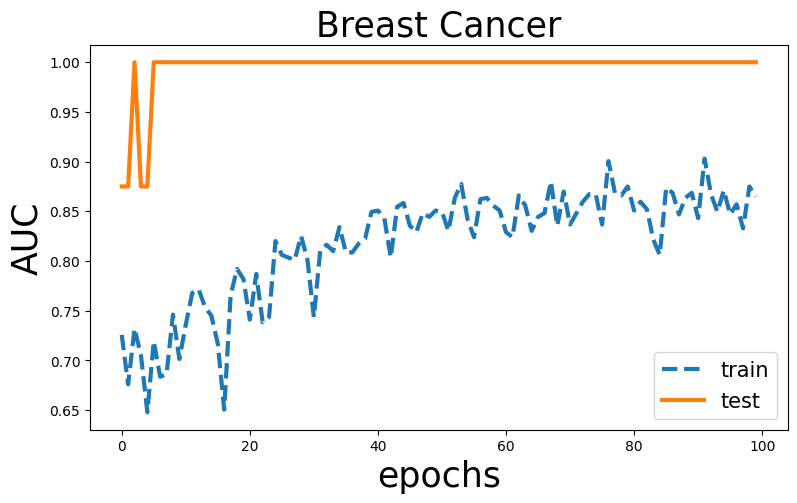

In [7]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_auc))

plt.figure()
plt.plot(x, train_auc, linestyle='--', label='train', linewidth=3)
plt.plot(x, test_auc, label='test', linewidth=3)
plt.title('Breast Cancer',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUC',fontsize=25)
plt.xlabel('epochs',fontsize=25)

# **Ablation Study on Attention Weights**

In [8]:
maxV = -1e10
maxbag = 0
for idx, data in enumerate(trainloader):
    y_pred = []
    sd = []
    train_data_bags, train_labels, ids = data
    for i in range(len(ids)):
        y_pred_bag, weights_bag = model(train_data_bags[i].float().cuda())
        value = torch.sum(y_pred_bag*weights_bag)/torch.sum(weights_bag)
        if value > maxV:
            maxV = value
            maxbag = train_data_bags[i]
            maxlabel = train_labels[i]
print(maxV)
print(maxlabel)

tensor(-1.9086, device='cuda:0', grad_fn=<DivBackward0>)
tensor([1.], dtype=torch.float64)


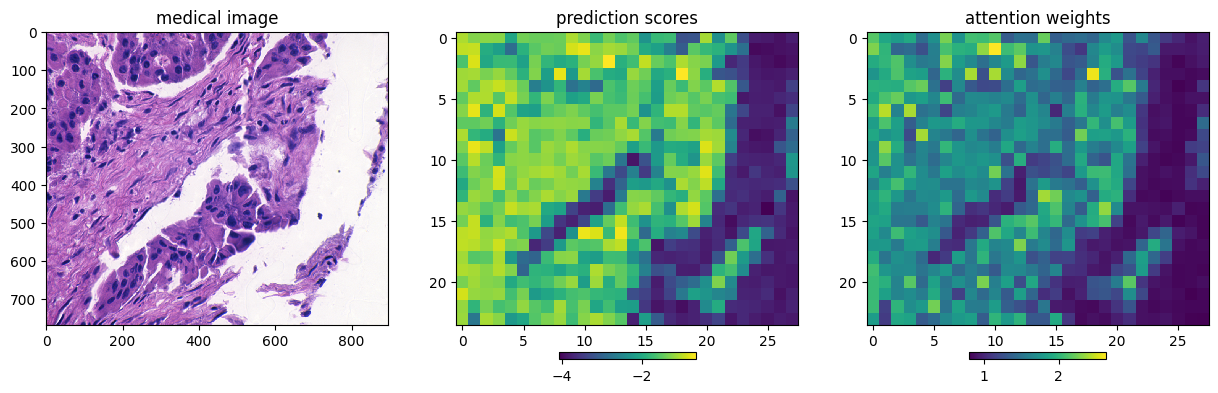

In [9]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
tmp = maxbag
tmp = tmp.numpy()
tmp = np.transpose(tmp,[0,2,3,1])
img = []
for i in range(24): # collate patches back to the original image arrangement
    tmpimg = []
    for j in range(28):
        tmpimg.append(tmp[i*28+j])
    tmpimg = np.concatenate(tmpimg, axis=1)
    img.append(tmpimg)
img = np.concatenate(img, axis=0)

y_pred_bag, weights_bag = model(maxbag.float().cuda())
weights = weights_bag.detach().cpu().numpy()
weights = np.reshape(weights, [24,28])

preds = y_pred_bag.detach().cpu().numpy()
preds = np.reshape(preds, [24,28])


fig, subfigs = plt.subplots(figsize=(15, 6), ncols=3)
imgax = subfigs[0]
predax = subfigs[1]
attax = subfigs[2]
imgfig = imgax.imshow(img, interpolation='nearest')
imgax.set_title('medical image')
predfig = predax.imshow(preds, interpolation=None, norm=None)
predax.set_title('prediction scores')
attfig = attax.imshow(weights, interpolation=None, norm=None)
attax.set_title('attention weights')
divider = make_axes_locatable(imgax)
cax = divider.new_vertical(size='5%', pad=0.1, pack_start = True)

plt.colorbar(imgfig, cax=cax, shrink=0.0, orientation = 'horizontal', pad=0.06)
plt.colorbar(predfig, ax=predax, shrink=0.4, orientation = 'horizontal', pad=0.06)
plt.colorbar(attfig, ax=attax, shrink=0.4, orientation = 'horizontal', pad=0.06)
plt.show()